Step 0:
     x1   x2   x3   x4   x5   RHS
B3  2.0  1.0  1.0  0.0  0.0  18.0
B4  2.0  3.0  0.0  1.0  0.0  42.0
B5  3.0  1.0  0.0  0.0  1.0  24.0
Z  -3.0 -2.0  0.0  0.0  0.0   0.0
----------------------------------------
Step 1:
     x1        x2   x3   x4        x5   RHS
B3  0.0  0.333333  1.0  0.0 -0.666667   2.0
B4  0.0  2.333333  0.0  1.0 -0.666667  26.0
B1  1.0  0.333333  0.0  0.0  0.333333   8.0
Z   0.0 -1.000000  0.0  0.0  1.000000  24.0
----------------------------------------
Step 2:
     x1   x2   x3   x4   x5   RHS
B2  0.0  1.0  3.0  0.0 -2.0   6.0
B4  0.0  0.0 -7.0  1.0  4.0  12.0
B1  1.0  0.0 -1.0  0.0  1.0   6.0
Z   0.0  0.0  3.0  0.0 -1.0  30.0
----------------------------------------
Step 3:
     x1   x2    x3    x4   x5   RHS
B2  0.0  1.0 -0.50  0.50  0.0  12.0
B5  0.0  0.0 -1.75  0.25  1.0   3.0
B1  1.0  0.0  0.75 -0.25  0.0   3.0
Z   0.0  0.0  1.25  0.25  0.0  33.0
----------------------------------------


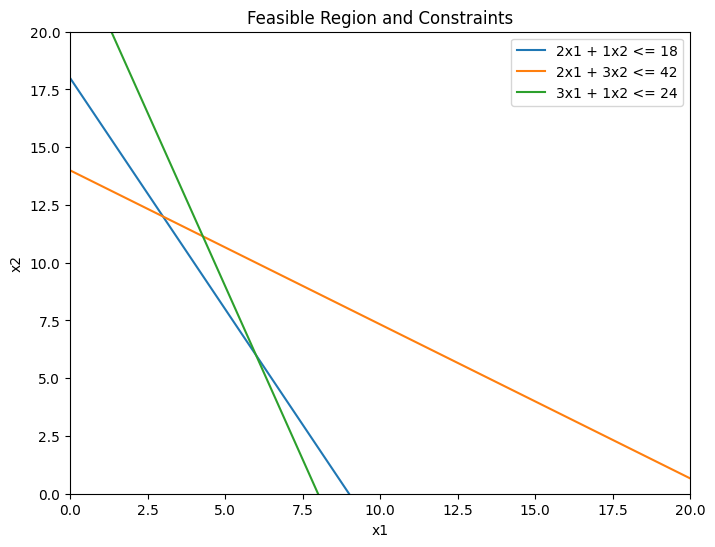

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simplex_method(c, A, b):
    """
    线性规划的单纯形法求解:
    maximize c^T x
    subject to Ax <= b, x >= 0
    """
    m, n = A.shape

    # 构造单纯形表
    table = np.zeros((m + 1, n + m + 1))
    table[:m, :n] = A
    table[:m, n:n+m] = np.eye(m)  # 添加单位矩阵
    table[:m, -1] = b  # 右端项
    table[-1, :n] = -c  # 目标函数系数

    basis = list(range(n, n+m))  # 初始基变量索引

    steps = []  # 记录每步的表格

    def log_step():
        df = pd.DataFrame(table, columns=[f"x{i+1}" for i in range(n+m)] + ["RHS"])
        df.index = [f"B{i+1}" for i in basis] + ["Z"]
        steps.append(df.copy())

    log_step()

    while True:
        # 选入基变量（找最负的系数）
        pivot_col = np.argmin(table[-1, :-1])
        if table[-1, pivot_col] >= 0:
            break  # 目标函数不再下降，找到最优解

        # 选出基变量（最小比值规则）
        ratios = np.array([table[i, -1] / table[i, pivot_col] if table[i, pivot_col] > 0 else np.inf for i in range(m)])
        pivot_row = np.argmin(ratios)
        if ratios[pivot_row] == np.inf:
            raise ValueError("问题无界")

        # 进行高斯消元
        table[pivot_row, :] /= table[pivot_row, pivot_col]
        for i in range(m+1):
            if i != pivot_row:
                table[i, :] -= table[i, pivot_col] * table[pivot_row, :]

        # 更新基变量
        basis[pivot_row] = pivot_col

        log_step()

    return table, steps, basis

# 示例：求解线性规划
c = np.array([3, 2])  # 目标函数系数 (Max Z = 3x1 + 2x2)
A = np.array([[2, 1], [2, 3], [3, 1]])  # 约束系数矩阵
b = np.array([18, 42, 24])  # 右端约束值

table, steps, basis = simplex_method(c, A, b)

# **显示每一步的表格**
for i, step in enumerate(steps):
    print(f"Step {i}:")
    print(step)
    print("-" * 40)

# **绘制约束可行域**
x1_vals = np.linspace(0, 20, 200)
plt.figure(figsize=(8, 6))

for i in range(A.shape[0]):
    plt.plot(x1_vals, (b[i] - A[i, 0] * x1_vals) / A[i, 1], label=f"{A[i, 0]}x1 + {A[i, 1]}x2 <= {b[i]}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.legend()
plt.title("Feasible Region and Constraints")
plt.show()



Step 0: 当前单纯形表如下
     x1   x2   x3   x4   x5  RHS
B3  2.0  3.0  1.0  0.0  0.0  6.0
B4  1.0  2.0  0.0  1.0  0.0  3.0
B5  3.0  2.0  0.0  0.0  1.0  5.0
Z  -4.0 -3.0  0.0  0.0  0.0  0.0
------------------------------------------------------------

Step 1: 选入基变量 x1，因为它的目标函数系数最负 (-4.0)
     x1        x2   x3   x4        x5       RHS
B3  0.0  1.666667  1.0  0.0 -0.666667  2.666667
B4  0.0  1.333333  0.0  1.0 -0.333333  1.333333
B1  1.0  0.666667  0.0  0.0  0.333333  1.666667
Z   0.0 -0.333333  0.0  0.0  1.333333  6.666667
------------------------------------------------------------

Step 1: 选出基变量 x5，因为它的约束比值最小 (1.6666666666666667)
     x1   x2   x3    x4    x5  RHS
B3  0.0  0.0  1.0 -1.25 -0.25  1.0
B2  0.0  1.0  0.0  0.75 -0.25  1.0
B1  1.0  0.0  0.0 -0.50  0.50  1.0
Z   0.0  0.0  0.0  0.25  1.25  7.0
------------------------------------------------------------


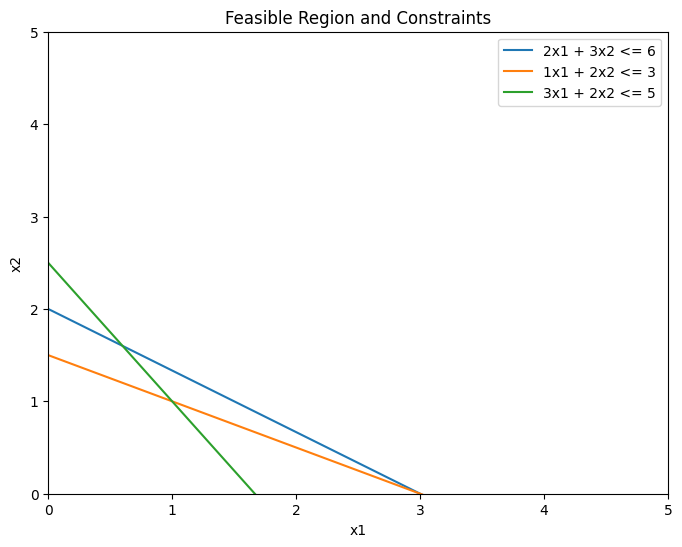

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def simplex_method_verbose(c, A, b):
    """
    详细版单纯形法，包含每一步的详细讲解。
    线性规划问题：
        maximize c^T x
        subject to Ax <= b, x >= 0
    """
    m, n = A.shape

    # 构造单纯形表
    table = np.zeros((m + 1, n + m + 1))
    table[:m, :n] = A
    table[:m, n:n+m] = np.eye(m)  # 添加单位矩阵
    table[:m, -1] = b  # 右端项
    table[-1, :n] = -c  # 目标函数系数

    basis = list(range(n, n+m))  # 初始基变量索引

    steps = []  # 存储每步的表格
    explanations = []  # 存储每一步的讲解

    def log_step(step_num):
        df = pd.DataFrame(table, columns=[f"x{i+1}" for i in range(n+m)] + ["RHS"])
        df.index = [f"B{i+1}" for i in basis] + ["Z"]
        steps.append(df.copy())
        explanations.append(f"Step {step_num}: 当前单纯形表如下")

    log_step(0)

    step_count = 1

    while True:
        # 选入基变量（找最负的系数）
        pivot_col = np.argmin(table[-1, :-1])
        if table[-1, pivot_col] >= 0:
            explanations.append("目标函数行没有负系数，找到最优解！")
            break

        explanations.append(f"Step {step_count}: 选入基变量 x{pivot_col+1}，因为它的目标函数系数最负 ({table[-1, pivot_col]})")

        # 选出基变量（最小比值规则）
        ratios = np.array([table[i, -1] / table[i, pivot_col] if table[i, pivot_col] > 0 else np.inf for i in range(m)])
        pivot_row = np.argmin(ratios)
        if ratios[pivot_row] == np.inf:
            raise ValueError("问题无界")

        explanations.append(f"Step {step_count}: 选出基变量 x{basis[pivot_row]+1}，因为它的约束比值最小 ({ratios[pivot_row]})")

        # 进行高斯消元
        pivot_val = table[pivot_row, pivot_col]
        table[pivot_row, :] /= pivot_val
        explanations.append(f"Step {step_count}: 归一化支点元素（{pivot_val}）")

        for i in range(m+1):
            if i != pivot_row:
                factor = table[i, pivot_col]
                table[i, :] -= factor * table[pivot_row, :]
                explanations.append(f"Step {step_count}: 用第 {pivot_row+1} 行消元第 {i+1} 行，使 x{pivot_col+1} 的系数变为 0")

        # 更新基变量
        basis[pivot_row] = pivot_col
        explanations.append(f"Step {step_count}: 替换基变量，x{pivot_col+1} 进入基，x{basis[pivot_row]+1} 退出基")

        log_step(step_count)
        step_count += 1

    return table, steps, explanations

# 复杂示例：求解
# maximize Z = 4x1 + 3x2
# subject to:
# 2x1 + 3x2 <= 6
# x1 + 2x2 <= 3
# 3x1 + 2x2 <= 5
# x1, x2 >= 0

c = np.array([4, 3])
A = np.array([[2, 3],
              [1, 2],
              [3, 2]])
b = np.array([6, 3, 5])

table, steps, explanations = simplex_method_verbose(c, A, b)

# 显示每个步骤
for i, (step, explanation) in enumerate(zip(steps, explanations)):
    print(f"\n{explanation}")
    print(step)
    print("-" * 60)

# 可视化约束可行域
x1_vals = np.linspace(0, 10, 200)
plt.figure(figsize=(8, 6))

for i in range(A.shape[0]):
    plt.plot(x1_vals, (b[i] - A[i, 0] * x1_vals) / A[i, 1], label=f"{A[i, 0]}x1 + {A[i, 1]}x2 <= {b[i]}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.legend()
plt.title("Feasible Region and Constraints")
plt.show()


In [2]:
import pandas as pd

# 读取Excel文件（假设数据在第一个Sheet）
file_path = r"F:\桌面\aCcA\管理统计\第2章数据的搜集、整理和展示\雨课堂-双一流高校.xlsx"
df = pd.read_excel(file_path)

In [5]:

if "所在地" not in df.columns:
    print("请检查数据中的省份列名称是否正确")
else:
    province_summary = df.groupby("所在地").size().reset_index(name="高校数量")

    province_summary = province_summary.sort_values(by="高校数量", ascending=False)
    print(province_summary)


    province_summary.to_excel("双一流高校省份统计.xlsx", index=False)


    所在地  高校数量
2    北京    22
13   江苏    13
0    上海    10
4    四川     6
19   湖北     5
26   陕西     5
28  黑龙江     3
10   广东     3
5    天津     3
7    安徽     2
3    吉林     2
24   辽宁     2
17   浙江     2
15   河北     2
11   广西     1
12   新疆     1
8    山东     1
6    宁夏     1
1   内蒙古     1
9    山西     1
16   河南     1
20   湖南     1
18   海南     1
14   江西     1
21   福建     1
23   贵州     1
22   西藏     1
25   重庆     1
27   青海     1


In [4]:
# 初始客人名单
guests = ['Zhang san', 'Li si', 'Wang wu', 'Zhao liu']

# 1. Zhao liu 说要带 Hu qi
guests.append('Hu qi')

# 2. Zhang san 因临时有事不能来了，需要删除
guests.remove('Zhang san')

# 3. Wang wu 由 Wang shi 代替，即替换
index = guests.index('Wang wu')  # 找到 Wang wu 的索引位置
guests[index] = 'Wang shi'  # 替换为 Wang shi

# 输出最终名单
print(guests)



['Li si', 'Wang shi', 'Zhao liu', 'Hu qi']


In [5]:
print(['zhang san', 'hu ba', 'wang wu', 'tan qi'])

['zhang san', 'hu ba', 'wang wu', 'tan qi']
